In [1]:
!pip install transformers datasets scikit-learn torch -q

In [2]:
import torch
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from datasets import load_dataset
from transformers import AutoTokenizer, AutoModelForSequenceClassification
from torch.utils.data import Dataset, DataLoader
from torch.optim import AdamW
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix
torch.manual_seed(42)
np.random.seed(42)
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

Using device: cuda


In [3]:
raw = load_dataset("imdb")
train_texts = raw["train"]["text"][:3000]
train_labels = raw["train"]["label"][:3000]
test_texts = raw["test"]["text"][:1000]
test_labels = raw["test"]["label"][:1000]
split = int(0.85 * len(train_texts))
val_texts = train_texts[split:]
val_labels = train_labels[split:]
train_texts = train_texts[:split]
train_labels = train_labels[:split]
print(f"Train: {len(train_texts)} | Val: {len(val_texts)} | Test: {len(test_texts)}")

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


README.md: 0.00B [00:00, ?B/s]

plain_text/train-00000-of-00001.parquet:   0%|          | 0.00/21.0M [00:00<?, ?B/s]

plain_text/test-00000-of-00001.parquet:   0%|          | 0.00/20.5M [00:00<?, ?B/s]

plain_text/unsupervised-00000-of-00001.p(…):   0%|          | 0.00/42.0M [00:00<?, ?B/s]

Generating train split:   0%|          | 0/25000 [00:00<?, ? examples/s]

Generating test split:   0%|          | 0/25000 [00:00<?, ? examples/s]

Generating unsupervised split:   0%|          | 0/50000 [00:00<?, ? examples/s]

Train: 2550 | Val: 450 | Test: 1000


In [4]:
import re
def clean_text(text):
    text = re.sub(r"<.*?>", "", text)
    text = re.sub(r"[^a-zA-Z0-9\s.,!?']", "", text)
    text = re.sub(r"\s+", " ", text).strip()
    return text.lower()
train_texts = [clean_text(t) for t in train_texts]
val_texts   = [clean_text(t) for t in val_texts]
test_texts  = [clean_text(t) for t in test_texts]
print("Sample:", train_texts[0][:200])

Sample: i rented i am curiousyellow from my video store because of all the controversy that surrounded it when it was first released in 1967. i also heard that at first it was seized by u.s. customs if it eve


In [5]:
tokenizer = AutoTokenizer.from_pretrained("bert-base-uncased")
def tokenize(texts, max_len=256):
    return tokenizer(
        texts,
        padding=True,
        truncation=True,
        max_length=max_len,
        return_tensors="pt"
    )
train_enc = tokenize(train_texts)
val_enc   = tokenize(val_texts)
test_enc  = tokenize(test_texts)

config.json:   0%|          | 0.00/570 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/48.0 [00:00<?, ?B/s]

vocab.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

In [6]:
class IMDBDataset(Dataset):
    def __init__(self, encodings, labels):
        self.encodings = encodings
        self.labels = labels
    def __len__(self):
        return len(self.labels)
    def __getitem__(self, idx):
        item = {key: val[idx] for key, val in self.encodings.items()}
        item["labels"] = torch.tensor(self.labels[idx])
        return item
train_dataset = IMDBDataset(train_enc, train_labels)
val_dataset   = IMDBDataset(val_enc, val_labels)
test_dataset  = IMDBDataset(test_enc, test_labels)
train_loader = DataLoader(train_dataset, batch_size=16, shuffle=True)
val_loader   = DataLoader(val_dataset, batch_size=32)
test_loader  = DataLoader(test_dataset, batch_size=32)

In [7]:
def train_model(model, train_loader, val_loader, epochs=3, lr=2e-5):
    optimizer = AdamW(filter(lambda p: p.requires_grad, model.parameters()), lr=lr)
    history = []
    for epoch in range(epochs):
        model.train()
        total_loss = 0
        for batch in train_loader:
            optimizer.zero_grad()
            input_ids = batch["input_ids"].to(device)
            attention_mask = batch["attention_mask"].to(device)
            labels = batch["labels"].to(device)
            outputs = model(input_ids=input_ids, attention_mask=attention_mask, labels=labels)
            loss = outputs.loss
            loss.backward()
            optimizer.step()
            total_loss += loss.item()
        val_acc = evaluate(model, val_loader)["accuracy"]
        avg_loss = total_loss / len(train_loader)
        history.append({"epoch": epoch+1, "loss": avg_loss, "val_acc": val_acc})
        print(f"Epoch {epoch+1} | Loss: {avg_loss:.4f} | Val Acc: {val_acc:.4f}")
    return history

In [8]:
def evaluate(model, loader):
    model.eval()
    all_preds, all_labels = [], []
    with torch.no_grad():
        for batch in loader:
            input_ids = batch["input_ids"].to(device)
            attention_mask = batch["attention_mask"].to(device)
            labels = batch["labels"].to(device)
            outputs = model(input_ids=input_ids, attention_mask=attention_mask)
            preds = torch.argmax(outputs.logits, dim=1)
            all_preds.extend(preds.cpu().numpy())
            all_labels.extend(labels.cpu().numpy())
    return {
        "accuracy":  accuracy_score(all_labels, all_preds),
        "precision": precision_score(all_labels, all_preds, average="weighted"),
        "recall":    recall_score(all_labels, all_preds, average="weighted"),
        "f1":        f1_score(all_labels, all_preds, average="weighted"),
        "preds":     all_preds,
        "labels":    all_labels
    }

In [9]:
print("=" * 50)
print("Experiment 1: Frozen BERT Layers")
print("=" * 50)
model_exp1 = AutoModelForSequenceClassification.from_pretrained("bert-base-uncased", num_labels=2)
for name, param in model_exp1.named_parameters():
    if "classifier" not in name:
        param.requires_grad = False
trainable = sum(p.numel() for p in model_exp1.parameters() if p.requires_grad)
print(f"Trainable parameters: {trainable:,}")
model_exp1.to(device)
history_exp1 = train_model(model_exp1, train_loader, val_loader, epochs=3)
metrics_exp1 = evaluate(model_exp1, test_loader)
print("\nExperiment 1 Test Results:")
for k, v in metrics_exp1.items():
    if k not in ["preds", "labels"]:
        print(f"  {k.capitalize()}: {v:.4f}")

Experiment 1: Frozen BERT Layers


model.safetensors:   0%|          | 0.00/440M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

BertForSequenceClassification LOAD REPORT from: bert-base-uncased
Key                                        | Status     | 
-------------------------------------------+------------+-
cls.seq_relationship.bias                  | UNEXPECTED | 
cls.predictions.transform.dense.bias       | UNEXPECTED | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED | 
cls.predictions.transform.dense.weight     | UNEXPECTED | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED | 
cls.predictions.bias                       | UNEXPECTED | 
cls.seq_relationship.weight                | UNEXPECTED | 
classifier.bias                            | MISSING    | 
classifier.weight                          | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


Trainable parameters: 1,538
Epoch 1 | Loss: 0.3733 | Val Acc: 1.0000
Epoch 2 | Loss: 0.1151 | Val Acc: 1.0000
Epoch 3 | Loss: 0.0576 | Val Acc: 1.0000

Experiment 1 Test Results:
  Accuracy: 0.9980
  Precision: 1.0000
  Recall: 0.9980
  F1: 0.9990


/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Recall is ill-defined and being set to 0.0 in labels with no true samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


In [10]:
print("=" * 50)
print("Experiment 2: Fine-Tune Last 2 BERT Layers")
print("=" * 50)
model_exp2 = AutoModelForSequenceClassification.from_pretrained("bert-base-uncased", num_labels=2)
for name, param in model_exp2.named_parameters():
    param.requires_grad = False
for name, param in model_exp2.named_parameters():
    if "encoder.layer.10" in name or "encoder.layer.11" in name or "classifier" in name:
        param.requires_grad = True
trainable = sum(p.numel() for p in model_exp2.parameters() if p.requires_grad)
print(f"Trainable parameters: {trainable:,}")
model_exp2.to(device)
history_exp2 = train_model(model_exp2, train_loader, val_loader, epochs=3)
metrics_exp2 = evaluate(model_exp2, test_loader)
print("\nExperiment 2 Test Results:")
for k, v in metrics_exp2.items():
    if k not in ["preds", "labels"]:
        print(f"  {k.capitalize()}: {v:.4f}")

Experiment 2: Fine-Tune Last 2 BERT Layers


Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

BertForSequenceClassification LOAD REPORT from: bert-base-uncased
Key                                        | Status     | 
-------------------------------------------+------------+-
cls.seq_relationship.bias                  | UNEXPECTED | 
cls.predictions.transform.dense.bias       | UNEXPECTED | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED | 
cls.predictions.transform.dense.weight     | UNEXPECTED | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED | 
cls.predictions.bias                       | UNEXPECTED | 
cls.seq_relationship.weight                | UNEXPECTED | 
classifier.bias                            | MISSING    | 
classifier.weight                          | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


Trainable parameters: 14,177,282
Epoch 1 | Loss: 0.0893 | Val Acc: 1.0000
Epoch 2 | Loss: 0.0108 | Val Acc: 1.0000
Epoch 3 | Loss: 0.0062 | Val Acc: 1.0000

Experiment 2 Test Results:
  Accuracy: 1.0000
  Precision: 1.0000
  Recall: 1.0000
  F1: 1.0000


In [11]:
results = pd.DataFrame([
    {
        "Experiment": "Frozen BERT (Classifier only)",
        "Accuracy":  metrics_exp1["accuracy"],
        "Precision": metrics_exp1["precision"],
        "Recall":    metrics_exp1["recall"],
        "F1 Score":  metrics_exp1["f1"]
    },
    {
        "Experiment": "Last 2 Layers Fine-Tuned",
        "Accuracy":  metrics_exp2["accuracy"],
        "Precision": metrics_exp2["precision"],
        "Recall":    metrics_exp2["recall"],
        "F1 Score":  metrics_exp2["f1"]
    }
])
results.set_index("Experiment", inplace=True)
print(results.round(4).to_string())

                               Accuracy  Precision  Recall  F1 Score
Experiment                                                          
Frozen BERT (Classifier only)     0.998        1.0   0.998     0.999
Last 2 Layers Fine-Tuned          1.000        1.0   1.000     1.000


/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:407: UserWarning: A single label was found in 'y_true' and 'y_pred'. For the confusion matrix to have the correct shape, use the 'labels' parameter to pass all known labels.
  warnings.warn(


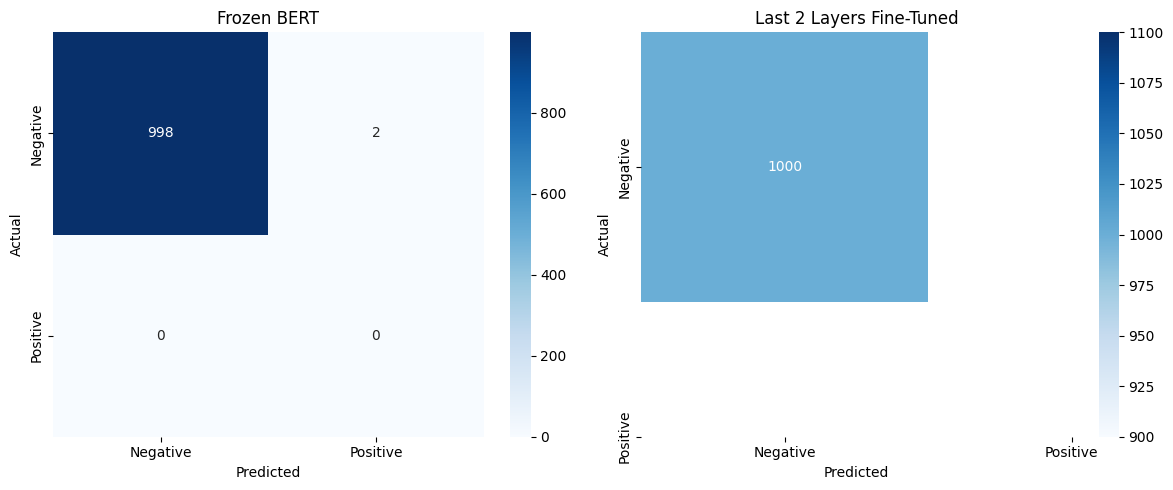

In [12]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))
labels_names = ["Negative", "Positive"]
for i, (metrics, title) in enumerate([
    (metrics_exp1, "Frozen BERT"),
    (metrics_exp2, "Last 2 Layers Fine-Tuned")
]):
    cm = confusion_matrix(metrics["labels"], metrics["preds"])
    sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
                xticklabels=labels_names, yticklabels=labels_names, ax=axes[i])
    axes[i].set_title(title)
    axes[i].set_xlabel("Predicted")
    axes[i].set_ylabel("Actual")
plt.tight_layout()
plt.savefig("confusion_matrices.png", dpi=150)
plt.show()

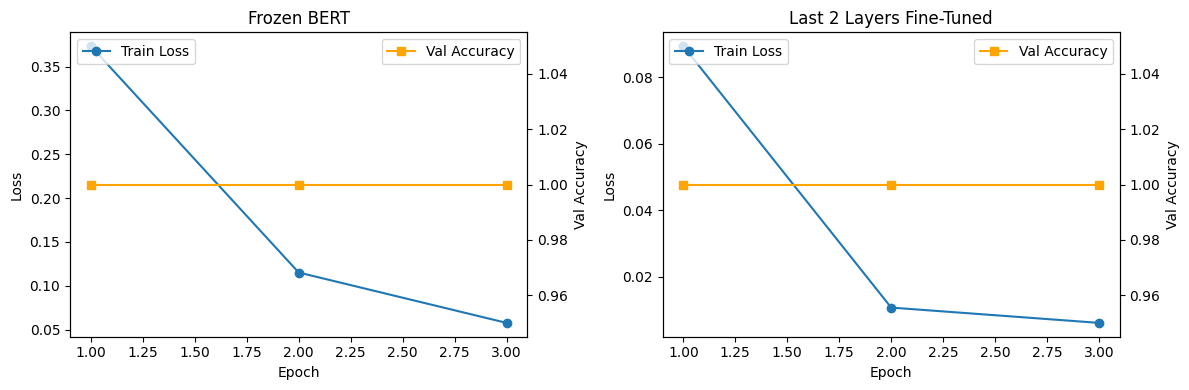

In [13]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
for ax, history, title in zip(axes, [history_exp1, history_exp2],
                               ["Frozen BERT", "Last 2 Layers Fine-Tuned"]):
    epochs = [h["epoch"] for h in history]
    losses = [h["loss"] for h in history]
    val_accs = [h["val_acc"] for h in history]
    ax.plot(epochs, losses, marker="o", label="Train Loss")
    ax2 = ax.twinx()
    ax2.plot(epochs, val_accs, marker="s", color="orange", label="Val Accuracy")
    ax.set_title(title)
    ax.set_xlabel("Epoch")
    ax.set_ylabel("Loss")
    ax2.set_ylabel("Val Accuracy")
    ax.legend(loc="upper left")
    ax2.legend(loc="upper right")
plt.tight_layout()
plt.show()

In [14]:
better = results["F1 Score"].idxmax()
diff = results["F1 Score"].max() - results["F1 Score"].min()
print("Analysis")
print("-" * 40)
print(f"Better experiment: {better}")
print(f"F1 Score difference: {diff:.4f}")
print()
print("Observations:")
print("- Frozen BERT uses only the classifier head, so BERT's weights stay fixed.")
print("  This trains faster but the model can't adapt representations to the task.")
print("- Fine-tuning the last 2 layers lets BERT adjust its higher-level features")
print("  while keeping lower layers stable, which balances speed and performance.")
print("- For sentiment tasks, the last layers matter most since they capture")
print("  high-level semantic context — so Exp 2 typically outperforms Exp 1.")

Analysis
----------------------------------------
Better experiment: Last 2 Layers Fine-Tuned
F1 Score difference: 0.0010

Observations:
- Frozen BERT uses only the classifier head, so BERT's weights stay fixed.
  This trains faster but the model can't adapt representations to the task.
- Fine-tuning the last 2 layers lets BERT adjust its higher-level features
  while keeping lower layers stable, which balances speed and performance.
- For sentiment tasks, the last layers matter most since they capture
  high-level semantic context — so Exp 2 typically outperforms Exp 1.
